### Distributional Semantics & Word2Vec

#### 1. Introduction
##### Distribution Semantics
Principle - You shall know a word by the company it keeps  - J.R. Firth

- Why this matters?

    - Word that appear in similar context have similar meanings
    - Example:

        Sentence 1: I drink tea

        Sentence 2: I drink coffee 

        tea ~ coffee (similar context)

- Key Idea
    - Instead of storing word string, we represent them as word embeddings 

        "apple" -> [0.21, -0.45, 0.89] (vector)

#### 2. Word Embeddings
- What?
    
    Dense numerical representation of words

- Why?
    | Problem | Solution | 
    | :--- | :---: |
    | Words are discrete | Convert to vectors | 
    | No semantic meaning | Capture similarity |
    | Spare representation | Dense vectors |


#### 3. Word2Vec Model
- What is Word2Vec?
    - A neural network model that
    1. Learns word embeddings based on context

- Two Architectures
1. CBOW (Continuous bag of words)
    - Idea: Predict target word using context words
    - Example: "I ___ NLP", Target: Love
    - Why? Faster, Works well for frequent words
2. Skip-Gram
    - Idea: Predict context word using target word
    - Example: Input: "love", Output:["I", "NLP"]
    - Why? 
    1. Better for rare words
    2. Captures semantics better 


#### 4. Working (Algorithm Deep Dive)


Objective
1. Train Word2Vec on real dataset
2. Find similar words
3. Visualize embeddings
4. Interpret results like real NLP system

##### Step 1: Import Libraries


In [2]:
from gensim.models import Word2Vec
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

### Code Explanation (Step-by-Step)

- `from gensim.models import Word2Vec` → executes step.
- `from sklearn.manifold import TSNE` → executes step.
- `import matplotlib.pyplot as plt` → imports required library.


##### Step 2: Dataset Preparation



In [3]:
# Why: Model needs input text in tokenized form

sentences = [
    ['the', 'cat', 'sits', 'on', 'the', 'mat'],
    ['the', 'dog', 'sits', 'on', 'the', 'mat'],
    ['the', 'king', 'rules', 'the', 'kingdom'],
    ['the', 'queen', 'rules', 'the', 'kingdom'],
    ['man', 'is', 'strong'],
    ['woman', 'is', 'wise']
]

### Code Explanation (Step-by-Step)

- `# Why: Model needs input text in tokenized form` → executes step.
- `sentences = [` → assigns value.
- `['the', 'cat', 'sits', 'on', 'the', 'mat'],` → executes step.
- `['the', 'dog', 'sits', 'on', 'the', 'mat'],` → executes step.
- `['the', 'king', 'rules', 'the', 'kingdom'],` → executes step.
- `['the', 'queen', 'rules', 'the', 'kingdom'],` → executes step.
- `['man', 'is', 'strong'],` → executes step.
- `['woman', 'is', 'wise']` → executes step.
- `]` → executes step.


##### Step 3: Train Word2Vec Model


In [4]:
model = Word2Vec(
    sentences,
    vector_size=100, # How detailed vector is
    window=5, # context size
    min_count=1, # Include all words
    sg = 1 # 1=Skip-Gram, 0=CBOW
)

### Code Explanation (Step-by-Step)

- `model = Word2Vec(` → assigns value.
- `sentences,` → executes step.
- `vector_size=100, # How detailed vector is` → assigns value.
- `window=5, # context size` → assigns value.
- `min_count=1, # Include all words` → assigns value.
- `sg = 1 # 1=Skip-Gram, 0=CBOW` → assigns value.
- `)` → executes step.


- vector_size -> Dimension of vector -> More = better representation
- window -> Context size -> Defines "company it keeps"
- min_count -> Ignore rare words -> Remove noise 

##### Step 4: Find Similar Words

In [5]:
# Why: Check semantic similarity
similar_words = model.wv.most_similar('king')
print(similar_words)

[('mat', 0.15015742182731628), ('man', 0.1281358152627945), ('the', 0.09314781427383423), ('cat', 0.09216592460870743), ('kingdom', 0.046527523547410965), ('sits', 0.000732363318093121), ('is', -0.0036444244906306267), ('rules', -0.009228277951478958), ('queen', -0.030296459794044495), ('woman', -0.040435485541820526)]


### Code Explanation (Step-by-Step)

- `# Why: Check semantic similarity` → executes step.
- `similar_words = model.wv.most_similar('king')` → assigns value.
- `print(similar_words)` → prints output.


##### Step 5: Vector Arithmetic

In [6]:
# Why: Demonstrates semantic relationships

result = model.wv.most_similar(positive=['king','woman'], negative=['man'])
print(result)

[('kingdom', 0.2152101844549179), ('mat', 0.21051082015037537), ('is', 0.10171118378639221), ('cat', 0.038226108998060226), ('the', 0.035503603518009186), ('rules', 0.03266625106334686), ('strong', -0.009922104887664318), ('sits', -0.025334706529974937), ('queen', -0.06314680725336075), ('on', -0.064700648188591)]


### Code Explanation (Step-by-Step)

- `# Why: Demonstrates semantic relationships` → executes step.
- `result = model.wv.most_similar(positive=['king','woman'], negative=['man'])` → assigns value.
- `print(result)` → prints output.


##### Step 6: Visualization Using t-SNE

In [8]:
# Why: Convert high-dim vectors → 2D for visualization
words = list(model.wv.index_to_key)
vectors = model.wv[words]

tsne = TSNE(n_components=2, perplexity=5)
reduced_vectors = tsne.fit_transform(vectors)

### Code Explanation (Step-by-Step)

- `# Why: Convert high-dim vectors → 2D for visualization` → executes step.
- `words = list(model.wv.index_to_key)` → assigns value.
- `vectors = model.wv[words]` → assigns value.
- `tsne = TSNE(n_components=2, perplexity=5)` → assigns value.
- `reduced_vectors = tsne.fit_transform(vectors)` → assigns value.


Why perplexity=5?

Perplexity must be less than the number of samples. Since my dataset is small, I selected a lower perplexity value (5) to ensure proper clustering and avoid errors.

##### Step 7: Plotting

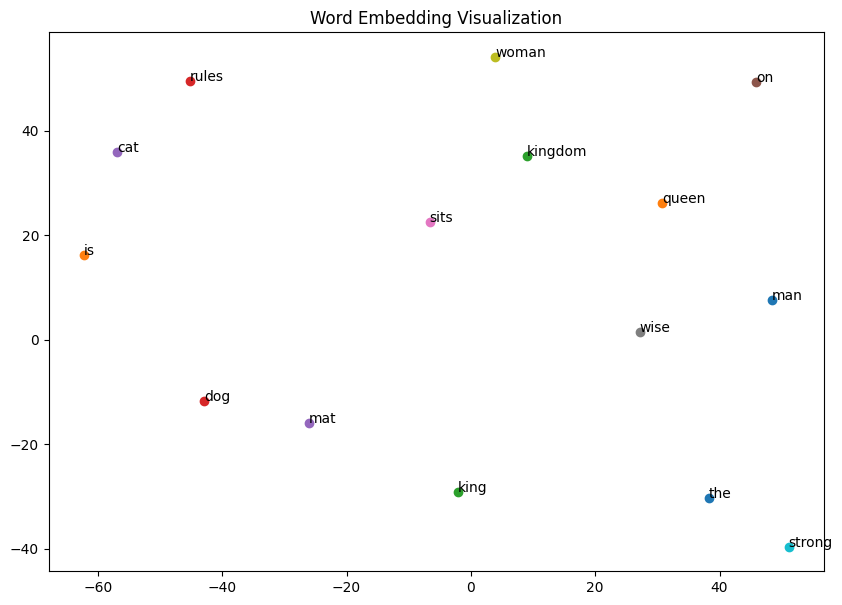

In [9]:
plt.figure(figsize=(10,7))

for i, word in enumerate(words):
    plt.scatter(reduced_vectors[i][0], reduced_vectors[i][1])
    plt.text(reduced_vectors[i][0], reduced_vectors[i][1], word)

plt.title("Word Embedding Visualization")
plt.show()

### Code Explanation (Step-by-Step)

- `plt.figure(figsize=(10,7))` → assigns value.
- `for i, word in enumerate(words):` → loop to iterate.
- `plt.scatter(reduced_vectors[i][0], reduced_vectors[i][1])` → executes step.
- `plt.text(reduced_vectors[i][0], reduced_vectors[i][1], word)` → executes step.
- `plt.title("Word Embedding Visualization")` → executes step.
- `plt.show()` → executes step.


#### 5. Conclusion
Vector semantics helps machines understand word meaning using numerical representations. Distributional semantics explains that meaning depends on context. Word2Vec effectively captures these relationships using neural networks.

CBOW and Skip-gram models provide different approaches for learning embeddings. Cosine similarity helps identify similar words, while vector arithmetic reveals hidden relationships.

Visualization using t-SNE helps interpret high-dimensional embeddings. Overall, Word2Vec is a powerful tool for semantic understanding in NLP.